# 04 — ARIMA (AutoRegressive Integrated Moving Average)

Implements an ARIMA model for financial time series forecasting.

ARIMA is a classical statistical model that captures:
- **AR (p):** how the current value depends on the last `p` values
- **I (d):** how many times the series needs to be differenced to become stationary
- **MA (q):** how the current value depends on the last `q` forecast errors

Unlike Moving Average, ARIMA uses the autocorrelation structure of the series to make smarter predictions.

**Input:** `data/processed/<TICKER>_train.csv` and `data/processed/<TICKER>_test.csv`

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')  # suppress statsmodels convergence warnings

## Parameters

All hyperparameters are defined here so they are easy to find and modify.

The ARIMA order `(p, d, q)` controls the model:
- `p` — number of past values used (autoregressive terms)
- `d` — number of differencing steps to make the series stationary (usually 1 for prices)
- `q` — number of past forecast errors used (moving average terms)

In [16]:
TICKER = 'AAPL'
P      = None  # autoregressive order  — auto-detected by PACF below
D      = None  # differencing order    — auto-detected by ADF below
Q      = None  # moving average order  — auto-detected by ACF below


## Load Data

In [17]:
train = pd.read_csv(f'../data/processed/{TICKER}_train.csv', index_col='Date', parse_dates=True)
test  = pd.read_csv(f'../data/processed/{TICKER}_test.csv',  index_col='Date', parse_dates=True)

print(f"Train: {len(train)} rows | Test: {len(test)} rows")

Train: 1205 rows | Test: 302 rows


## Stationarity Check — ADF Test

ARIMA requires the series to be **stationary** (constant mean and variance over time).
Raw stock prices are not stationary — they trend upward over time.

The **Augmented Dickey-Fuller (ADF)** test checks this formally:
- **p-value < 0.05** → series is stationary (we can use d=0)
- **p-value ≥ 0.05** → series is NOT stationary (we need d=1 or more)

We test both the raw prices and the first-differenced prices to confirm that `d=1` is correct.

In [18]:
def adf_test(series):
    result = adfuller(series.dropna())
    return result[1]  # return p-value

close = train['Close']

# Test raw prices
pval_raw = adf_test(close)
print(f"Raw prices       — p-value: {pval_raw:.4f} → {'Stationary' if pval_raw < 0.05 else 'NOT stationary'}")

# Test first-differenced prices
pval_diff1 = adf_test(close.diff())
print(f"First difference — p-value: {pval_diff1:.4f} → {'Stationary' if pval_diff1 < 0.05 else 'NOT stationary'}")

# Auto-detect D:
# d=0 → raw series already stationary
# d=1 → first difference is stationary (typical for stock prices)
# d=2 → need to difference twice (rare)
if pval_raw < 0.05:
    D = 0
elif pval_diff1 < 0.05:
    D = 1
else:
    D = 2

print(f"\nAuto-detected D = {D}")


Raw prices       — p-value: 0.7571 → NOT stationary
First difference — p-value: 0.0000 → Stationary

Auto-detected D = 1


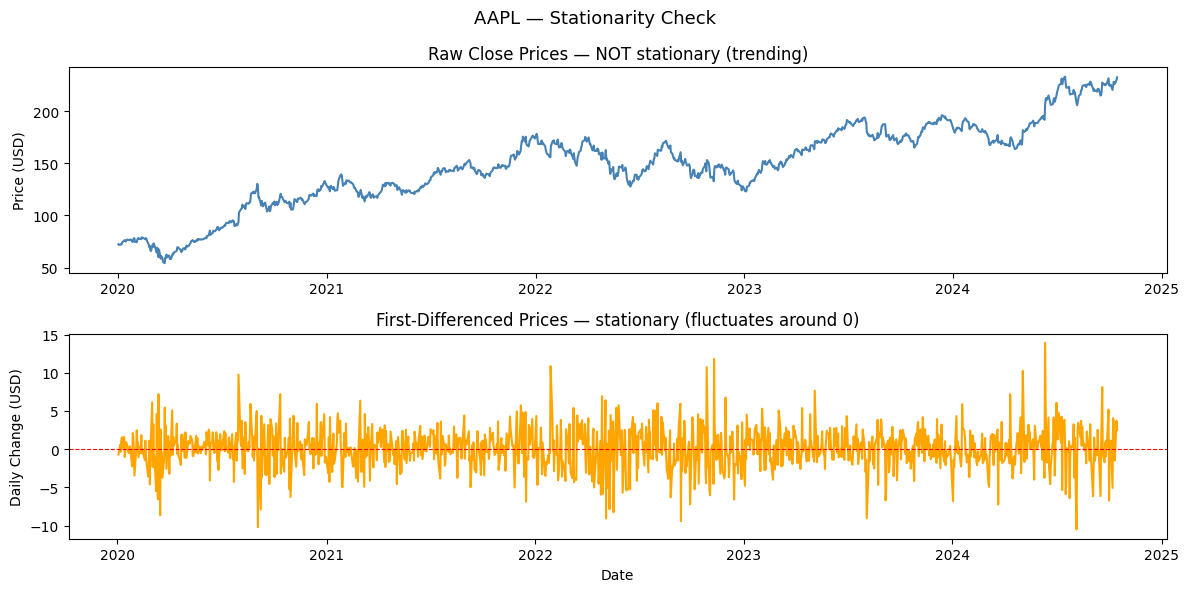

In [19]:
# Visual stationarity check:
# Raw prices trend upward → NOT stationary (mean changes over time)
# First-differenced prices fluctuate around 0 → stationary

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
fig.suptitle(f'{TICKER} — Stationarity Check', fontsize=13)

# Raw prices — should show a clear trend (non-stationary)
axes[0].plot(train.index, train['Close'], color='steelblue')
axes[0].set_title('Raw Close Prices — NOT stationary (trending)')
axes[0].set_ylabel('Price (USD)')

# First difference — should fluctuate around zero (stationary)
axes[1].plot(train.index, train['Close'].diff(), color='orange')
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[1].set_title('First-Differenced Prices — stationary (fluctuates around 0)')
axes[1].set_ylabel('Daily Change (USD)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()


## Finding ARIMA Parameters — ACF & PACF + Auto ARIMA

We use two approaches to determine `(p, d, q)`:

1. **Manual — ACF/PACF:** read the plots and apply a consecutive cutoff rule
2. **Auto ARIMA:** `pmdarima.auto_arima` searches over combinations and picks the best by AIC

Both results are printed at the end so you can compare them.

- **PACF** → guides `p` (AR order): count consecutive significant bars from lag 1
- **ACF** → guides `q` (MA order): count consecutive significant bars from lag 1


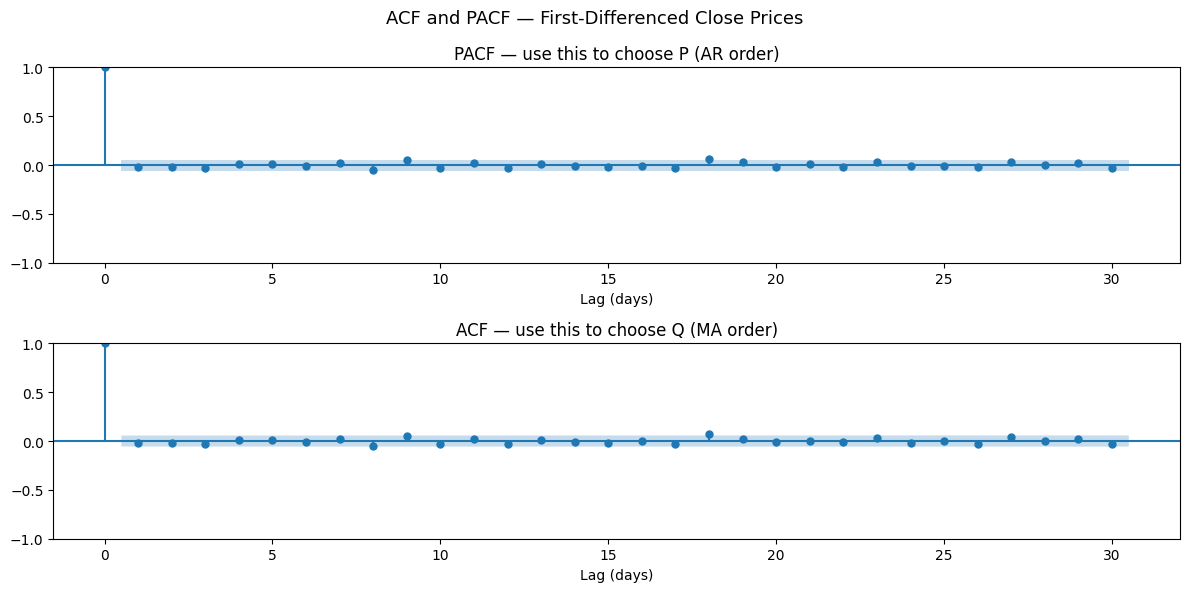

Confidence threshold : ±0.0565
Consecutive PACF lags significant → P = 1
Consecutive ACF lags significant  → Q = 0

Auto-detected order: ARIMA(1, 1, 0)


In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

# Difference the series once — ACF/PACF must be run on a stationary series
close_diff = train['Close'].diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
fig.suptitle('ACF and PACF — First-Differenced Close Prices', fontsize=13)

plot_pacf(close_diff, lags=30, ax=axes[0], method='ywm')
axes[0].set_title('PACF — use this to choose P (AR order)')
axes[0].set_xlabel('Lag (days)')

plot_acf(close_diff, lags=30, ax=axes[1])
axes[1].set_title('ACF — use this to choose Q (MA order)')
axes[1].set_xlabel('Lag (days)')

plt.tight_layout()
plt.show()

# Auto-detect P and Q using consecutive cutoff:
# Walk lags 1, 2, 3... and stop at the first lag that is NOT significant.
# This avoids picking up spurious significant lags at higher lags.
n         = len(close_diff)
threshold = 1.96 / np.sqrt(n)

pacf_vals = pacf(close_diff, nlags=20, method='ywm')
acf_vals  = acf(close_diff,  nlags=20)

def consecutive_cutoff(values, threshold):
    """Return the number of consecutive significant lags starting from lag 1."""
    count = 0
    for lag in range(1, len(values)):
        if abs(values[lag]) > threshold:
            count += 1
        else:
            break  # stop at the first non-significant lag
    return count

P = consecutive_cutoff(pacf_vals, threshold) or 1  # fallback to 1
Q = consecutive_cutoff(acf_vals,  threshold) or 0  # fallback to 0

print(f"Confidence threshold : ±{threshold:.4f}")
print(f"Consecutive PACF lags significant → P = {P}")
print(f"Consecutive ACF lags significant  → Q = {Q}")
print(f"\nAuto-detected order: ARIMA({P}, {D}, {Q})")


In [21]:
from pmdarima import auto_arima

# auto_arima searches over (p, d, q) combinations and selects the one
# with the lowest AIC (Akaike Information Criterion) — lower AIC = better fit
auto_model = auto_arima(
    train['Close'],
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=None,           # let auto_arima determine d via its own stationarity test
    seasonal=False,   # no seasonal component for daily stock prices
    stepwise=True,    # faster search (greedy)
    information_criterion='aic',
    suppress_warnings=True,
    error_action='ignore',
)

auto_p, auto_d, auto_q = auto_model.order

print("=" * 40)
print("Parameter Comparison")
print("=" * 40)
print(f"  Manual (ACF/PACF) : ARIMA({P}, {D}, {Q})")
print(f"  Auto ARIMA (AIC)  : ARIMA({auto_p}, {auto_d}, {auto_q})")
print()
print(f"Auto ARIMA AIC: {auto_model.aic():.2f}")
print()

# Use auto_arima values for the rolling forecast
P, D, Q = auto_p, auto_d, auto_q
print(f"Using ARIMA({P}, {D}, {Q}) for rolling forecast")


Parameter Comparison
  Manual (ACF/PACF) : ARIMA(1, 1, 0)
  Auto ARIMA (AIC)  : ARIMA(0, 1, 0)

Auto ARIMA AIC: 5776.80

Using ARIMA(0, 1, 0) for rolling forecast


## Rolling Forecast

A single fit on training data would not be realistic — in production, you would retrain as new data arrives.

We simulate this with a **rolling (expanding window) forecast**:
- Start with all training data
- For each test day: fit ARIMA on everything seen so far, predict one step ahead
- Add the actual observed value to the history and repeat

This is the most honest evaluation strategy for time series models.

**Note:** this is slow because ARIMA is refit for each test step. For 302 test points it takes a few minutes.

In [22]:
history     = list(train['Close'].values)  # start with all training data
predictions = []

for i, actual in enumerate(test['Close'].values):
    # Fit ARIMA on everything seen so far
    model = ARIMA(history, order=(P, D, Q))
    fit   = model.fit()

    # Predict one step ahead
    yhat = fit.forecast(steps=1)[0]
    predictions.append(yhat)

    # Add the actual observation to history (expanding window)
    history.append(actual)

    if (i + 1) % 50 == 0:
        print(f"Step {i + 1}/{len(test)} done")

predictions = np.array(predictions)
actuals     = test['Close'].values

print(f"\nDone. Predictions: {predictions.shape} | Actuals: {actuals.shape}")

Step 50/302 done
Step 100/302 done
Step 150/302 done
Step 200/302 done
Step 250/302 done
Step 300/302 done

Done. Predictions: (302,) | Actuals: (302,)


## Metrics

MAE:  2.6870
RMSE: 4.0447
MAPE: 1.1981%


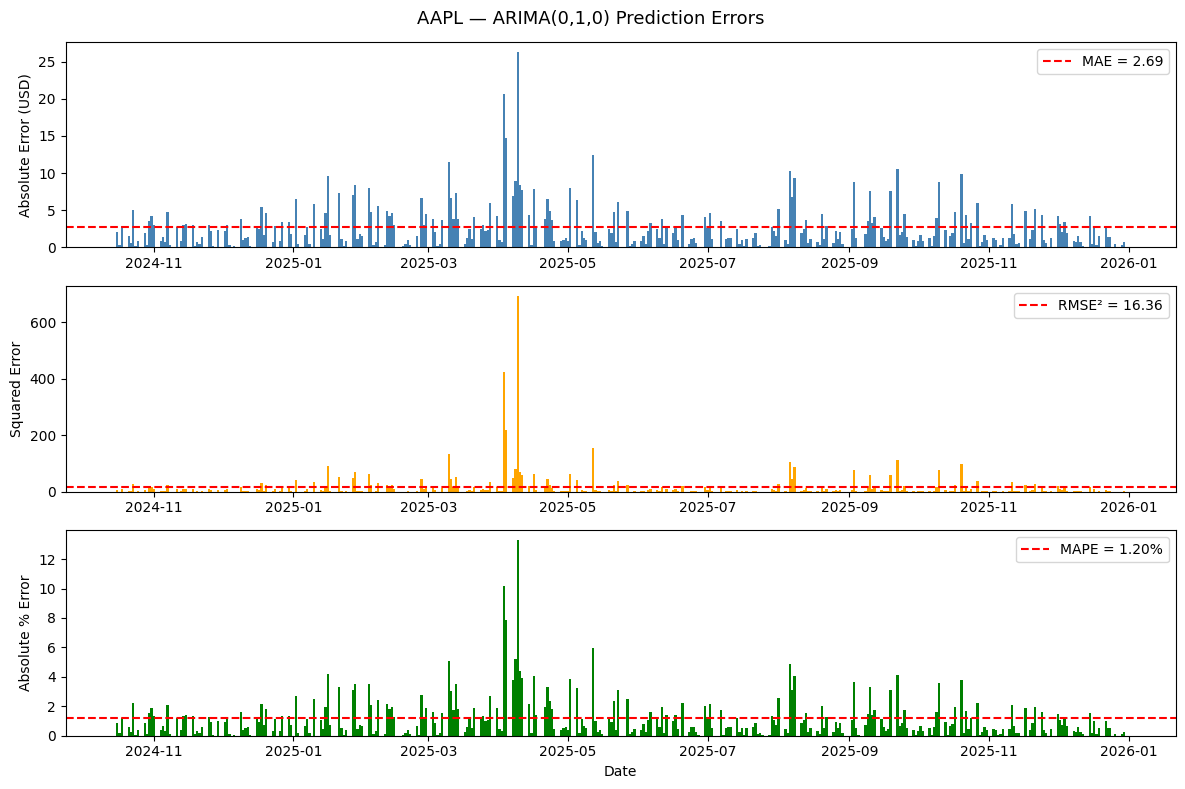

In [23]:
mae  = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}%")

# Daily prediction error (actual - predicted)
errors = actuals - predictions

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
fig.suptitle(f'{TICKER} — ARIMA({P},{D},{Q}) Prediction Errors', fontsize=13)

# MAE — absolute error per day
axes[0].bar(test.index, np.abs(errors), color='steelblue', width=1)
axes[0].axhline(mae, color='red', linestyle='--', label=f'MAE = {mae:.2f}')
axes[0].set_ylabel('Absolute Error (USD)')
axes[0].legend()

# RMSE — squared error per day
axes[1].bar(test.index, errors**2, color='orange', width=1)
axes[1].axhline(rmse**2, color='red', linestyle='--', label=f'RMSE² = {rmse**2:.2f}')
axes[1].set_ylabel('Squared Error')
axes[1].legend()

# MAPE — percentage error per day
pct_errors = np.abs((actuals - predictions) / actuals) * 100
axes[2].bar(test.index, pct_errors, color='green', width=1)
axes[2].axhline(mape, color='red', linestyle='--', label=f'MAPE = {mape:.2f}%')
axes[2].set_ylabel('Absolute % Error')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.tight_layout()
plt.show()

## Plot — Actual vs Predicted

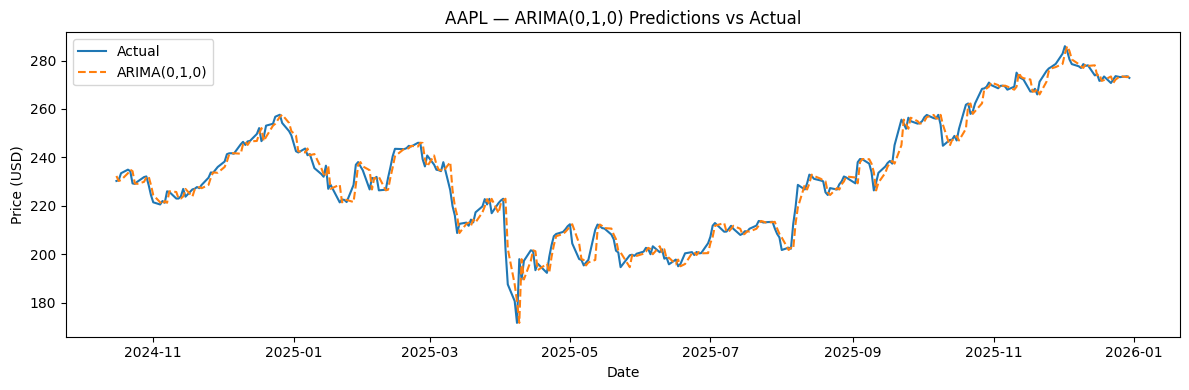

In [24]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(test.index, actuals,     label='Actual')
ax.plot(test.index, predictions, label=f'ARIMA({P},{D},{Q})', linestyle='--')
ax.set_title(f'{TICKER} — ARIMA({P},{D},{Q}) Predictions vs Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()